In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mtb
import seaborn as sns

In [3]:
df=pd.read_csv(r'C:\ML_PROJECT\pulsar_data_train.csv')

In [4]:
df.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298,0.0
1,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975,0.0
2,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324,0.0
3,156.398438,48.865942,-0.215989,-0.171294,17.471572,NaN,2.958066,7.197842,0.0
4,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128,0.0


In [5]:
df.tail()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
12523,124.312500,53.179053,-0.012418,-0.556021,7.186455,29.308266,4.531382,21.725143,0.0
12524,115.617188,46.784600,0.218177,0.226757,6.140468,NaN,5.732201,34.357283,0.0
12525,116.031250,43.213846,0.663456,0.433088,0.785117,11.628149,17.055215,312.204325,0.0
12526,135.664062,49.933749,-0.089940,-0.226726,3.859532,21.501505,7.398395,62.334018,0.0
12527,120.726562,50.472256,0.346178,0.184797,0.769231,11.792603,17.662222,329.548016,0.0


In [6]:
df.shape


(12528, 9)

In [89]:
df.value_counts()

 Mean of the integrated profile   Standard deviation of the integrated profile   Excess kurtosis of the integrated profile   Skewness of the integrated profile   Mean of the DM-SNR curve   Standard deviation of the DM-SNR curve   Excess kurtosis of the DM-SNR curve   Skewness of the DM-SNR curve  target_class
6.187500                         30.853928                                       6.476885                                   42.920763                            138.195652                 49.304496                                 0.393867                              0.097969                      1.0             1
6.265625                         31.535319                                       6.141778                                   39.078306                            135.020067                 55.575715                                 0.260257                             -0.917726                      1.0             1
6.414062                         30.920141               

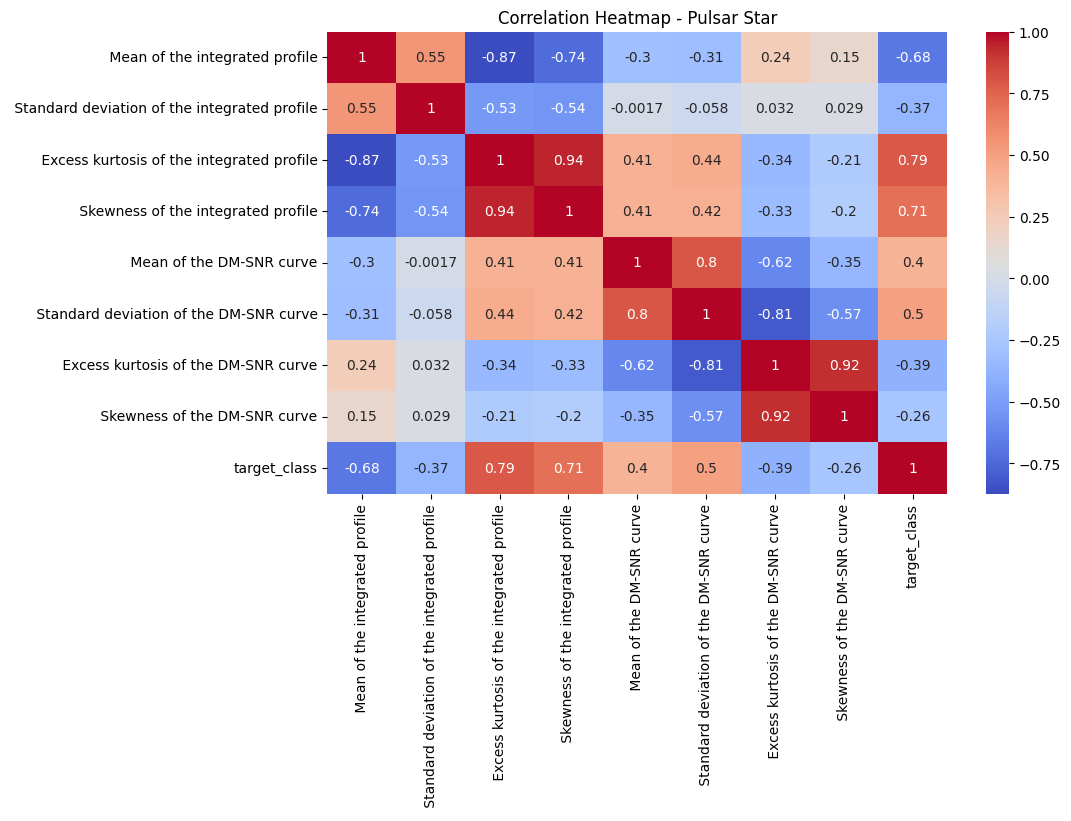

In [ ]:
mtb.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
mtb.title("Correlation Heatmap - Pulsar Star")
mtb.show()


In [11]:
class_0 = df[df["target_class"] == 0]
class_1 = df[df["target_class"] == 1]


In [12]:
print("Class 0 size:", class_0.shape)
print("Class 1 size:", class_1.shape)

Class 0 size: (11375, 9)
Class 1 size: (1153, 9)


In [13]:
class_0_sample = class_0.sample(n=1100, random_state=42)
class_1_sample = class_1.sample(n=1100, random_state=42)

In [27]:
class_0_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1100 entries, 273 to 5743
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                1100 non-null   float64
 1    Standard deviation of the integrated profile  1100 non-null   float64
 2    Excess kurtosis of the integrated profile     959 non-null    float64
 3    Skewness of the integrated profile            1100 non-null   float64
 4    Mean of the DM-SNR curve                      1100 non-null   float64
 5    Standard deviation of the DM-SNR curve        995 non-null    float64
 6    Excess kurtosis of the DM-SNR curve           1100 non-null   float64
 7    Skewness of the DM-SNR curve                  1043 non-null   float64
 8   target_class                                   1100 non-null   float64
dtypes: float64(9)
memory usage: 85.9 KB


In [15]:
balanced_df = pd.concat([class_0_sample, class_1_sample])
balanced_df

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
273,90.125000,42.903416,0.694571,1.105028,2.301003,NaN,9.050779,114.213809,0.0
6691,112.398438,51.912839,0.078931,-0.243554,3.209866,20.413131,8.706795,84.093180,0.0
7261,115.070312,48.212288,NaN,0.153865,4.385452,26.986143,6.683398,45.698091,0.0
5983,117.960938,51.588274,0.166451,-0.261494,3.161371,19.577516,7.604437,64.483369,0.0
12250,127.265625,49.595628,0.026180,-0.095198,2.742475,15.365466,8.296467,90.681156,0.0
...,...,...,...,...,...,...,...,...,...
8018,40.398438,33.748458,3.933903,19.294670,96.349498,NaN,0.558779,-0.717264,1.0
4341,51.750000,35.289428,NaN,12.660232,28.056020,65.487325,2.198025,3.374352,1.0
7740,52.000000,41.982139,2.247982,5.826078,123.467391,67.938540,0.356265,-0.855170,1.0
6110,29.382812,38.108218,3.811108,15.345561,129.897157,66.801723,0.270565,-1.021757,1.0


In [20]:
from sklearn.utils import shuffle
balanced_df=shuffle(balanced_df,random_state=42)
balanced_df.head(10)

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
10614,37.585938,60.302561,2.222210,3.719046,70.996656,72.373532,0.963634,-0.246372,1.0
7987,59.437500,38.901669,2.506677,9.072248,30.692308,61.686287,2.069241,3.363576,1.0
9097,109.171875,54.999163,0.544094,-0.163703,1.983278,14.179855,10.120656,129.004891,0.0
7316,113.179688,44.550258,0.174893,0.436464,2.309365,14.620950,10.145910,132.925636,0.0
1581,19.414062,46.191099,3.705014,13.046057,96.028428,61.410014,0.610825,-0.194555,1.0
6291,127.250000,45.399098,NaN,0.303495,6.393813,33.970594,5.559185,30.623632,1.0
7448,9.976562,32.258590,5.859134,35.459422,68.934783,65.174611,0.742921,-0.089009,1.0
6226,94.390625,37.358950,NaN,2.071257,3.320234,16.418756,7.386260,72.793856,0.0
4681,96.320312,46.136674,NaN,1.625057,4.243311,26.746490,7.110978,NaN,1.0
12380,55.875000,33.682340,2.734161,12.058390,11.163880,40.077975,4.024835,16.182925,1.0


In [22]:
balanced_df.tail()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
19,133.125000,59.957276,0.012855,-0.804890,31.553512,65.236254,1.735180,1.358508,0.0
7283,126.953125,51.441693,-0.109572,-0.353297,1.913880,11.905218,11.912163,NaN,0.0
11961,106.945312,39.873297,0.180394,0.938829,2.251672,17.214835,9.399114,99.008469,0.0
1661,80.531250,43.516868,1.199866,2.200255,69.884615,88.241308,0.822128,-0.870616,0.0
1986,16.523438,32.931028,NaN,32.826427,94.194816,71.694992,0.553430,-0.412870,1.0


In [24]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2200 entries, 10614 to 1986
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                2200 non-null   float64
 1    Standard deviation of the integrated profile  2200 non-null   float64
 2    Excess kurtosis of the integrated profile     1908 non-null   float64
 3    Skewness of the integrated profile            2200 non-null   float64
 4    Mean of the DM-SNR curve                      2200 non-null   float64
 5    Standard deviation of the DM-SNR curve        1996 non-null   float64
 6    Excess kurtosis of the DM-SNR curve           2200 non-null   float64
 7    Skewness of the DM-SNR curve                  2083 non-null   float64
 8   target_class                                   2200 non-null   float64
dtypes: float64(9)
memory usage: 171.9 KB


In [29]:
balanced_df.shape

(2200, 9)

In [34]:
balanced_df.isna().sum()

 Mean of the integrated profile                    0
 Standard deviation of the integrated profile      0
 Excess kurtosis of the integrated profile       292
 Skewness of the integrated profile                0
 Mean of the DM-SNR curve                          0
 Standard deviation of the DM-SNR curve          204
 Excess kurtosis of the DM-SNR curve               0
 Skewness of the DM-SNR curve                    117
target_class                                       0
dtype: int64

In [72]:
balanced_df.loc[:, :] = balanced_df.fillna(balanced_df.mean())


In [37]:
balanced_df.isna().sum().sum()

np.int64(0)

In [38]:
balanced_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2200 entries, 10614 to 1986
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                2200 non-null   float64
 1    Standard deviation of the integrated profile  2200 non-null   float64
 2    Excess kurtosis of the integrated profile     2200 non-null   float64
 3    Skewness of the integrated profile            2200 non-null   float64
 4    Mean of the DM-SNR curve                      2200 non-null   float64
 5    Standard deviation of the DM-SNR curve        2200 non-null   float64
 6    Excess kurtosis of the DM-SNR curve           2200 non-null   float64
 7    Skewness of the DM-SNR curve                  2200 non-null   float64
 8   target_class                                   2200 non-null   float64
dtypes: float64(9)
memory usage: 171.9 KB


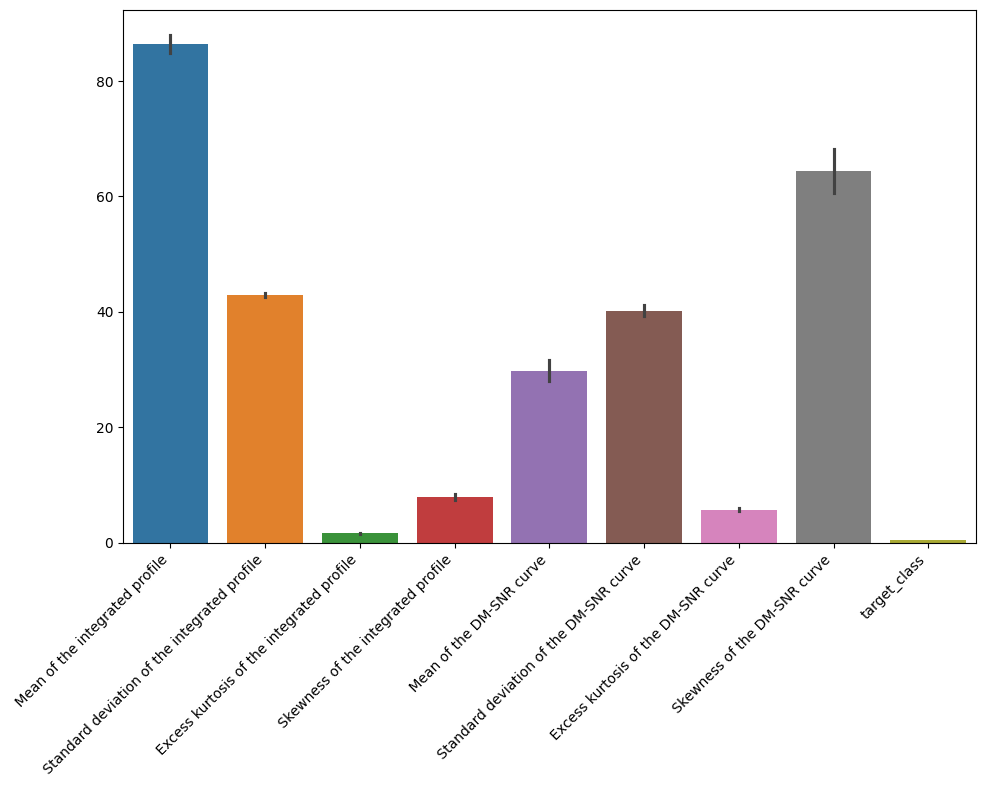

In [107]:
mtb.figure(figsize=(10,8))
sns.barplot(data=balanced_df)

mtb.xticks(rotation=45, ha="right")
mtb.tight_layout()
mtb.show()


<Axes: xlabel=' Mean of the integrated profile', ylabel='Density'>

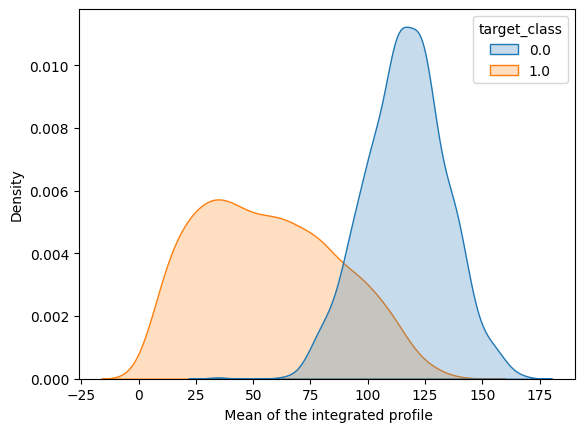

In [43]:
sns.kdeplot(data=balanced_df, x=' Mean of the integrated profile', hue='target_class', fill=True)   


(array([11375.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,  1153.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

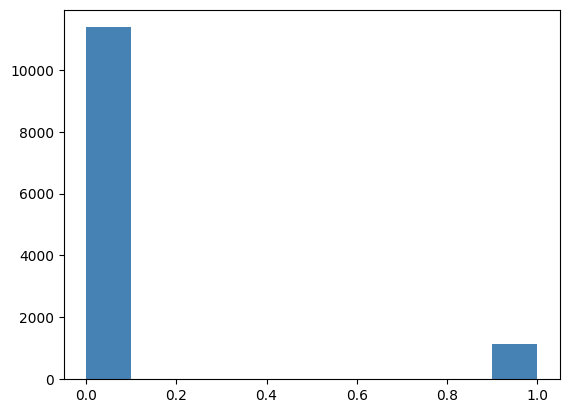

In [39]:
mtb.hist(df['target_class'], bins=10, color='steelblue')


<Axes: xlabel='target_class', ylabel=' Mean of the integrated profile'>

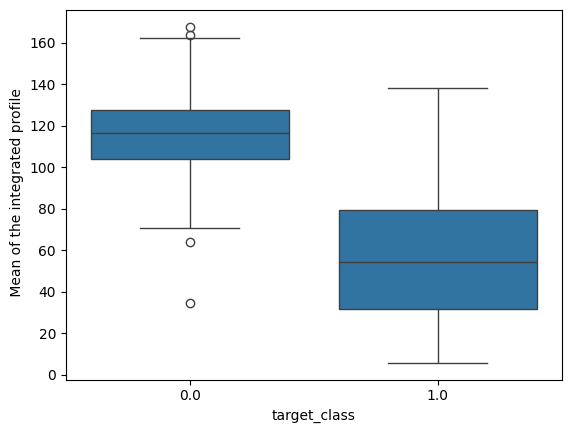

In [40]:
sns.boxplot(data=balanced_df, x='target_class', y=' Mean of the integrated profile')


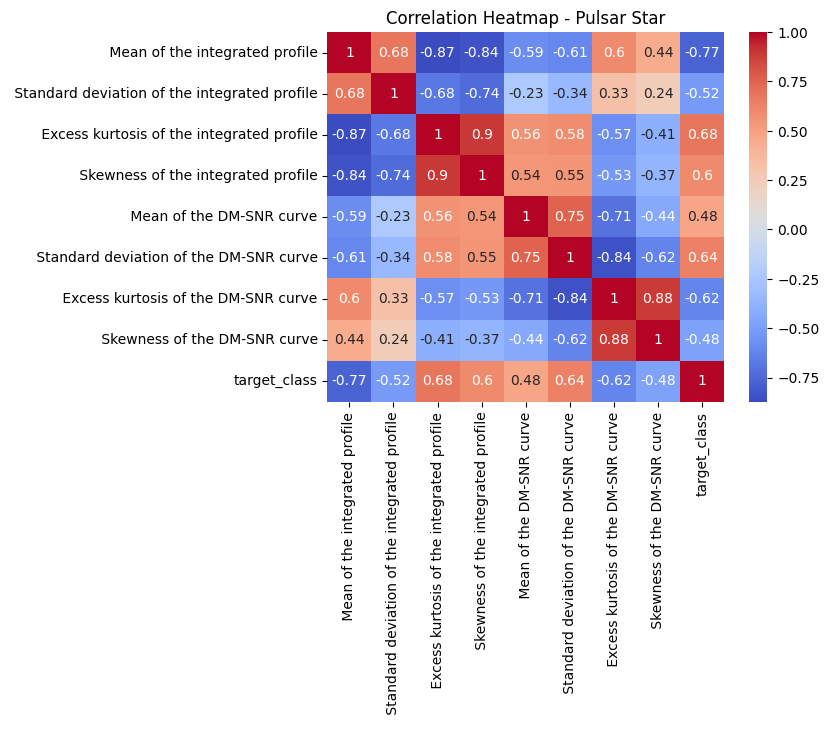

In [46]:

sns.heatmap(balanced_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
mtb.title("Correlation Heatmap - Pulsar Star")
mtb.show()


In [16]:
X = balanced_df.drop("target_class", axis=1)
y = balanced_df["target_class"]


In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [90]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [74]:
y.value_counts(normalize=True)


target_class
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

In [75]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced')


In [ ]:
# Fixing NaN 
X = X.apply(pd.to_numeric, errors="coerce")
X.fillna(X.mean(), inplace=True)

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# training
model = LogisticRegression(penalty='l1', solver='liblinear')
model.fit(X_scaled, y)


c:\ML_PROJECT\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\ML_PROJECT\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [85]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)

model.fit(X_train_scaled, y_train)


c:\ML_PROJECT\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\ML_PROJECT\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [86]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]


In [87]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm


array([[214,   6],
       [ 21, 199]])

In [88]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.91      0.97      0.94       220
         1.0       0.97      0.90      0.94       220

    accuracy                           0.94       440
   macro avg       0.94      0.94      0.94       440
weighted avg       0.94      0.94      0.94       440

